# VAR-X Model — Nepal Remittance Forecasting
**Project:** Predicting Nepal's Remittance Inflows Using DOFE Labour Departure Records as a 1–6 Month Leading Indicator  

---
**Model:** VAR-X (Vector Autoregression with Exogenous Variables)  
**Endogenous:** remittance, exchange_rate  
**Exogenous:** oil_price, dofe_lag3, dofe_lag6, dofe_lag9, covid_shock  
**Test period:** Jan 2024 – Nov 2025 (n=23)

## Step 0 — Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller, kpss, grangercausalitytests
from statsmodels.stats.stattools import durbin_watson
from scipy.stats import pearsonr, spearmanr

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10
print('All imports OK')

All imports OK


## Step 1 — Load Data

In [2]:
df = pd.read_csv(
    r"C:\Users\DELL\Desktop\remi\remittance-forecasting\output\remittance_2012_2025_model_ready.csv",
    parse_dates=['date']
)
df = df.sort_values('date').reset_index(drop=True)
df.set_index('date', inplace=True)
df.index.freq = 'MS'

print(f'Loaded : {df.shape[0]} rows  |  {df.index[0].date()} -> {df.index[-1].date()}')
print(f'Columns: {list(df.columns)}')
print(f'Missing:\n{df.isnull().sum()}')
df.head()

Loaded : 151 rows  |  2013-05-01 -> 2025-11-01
Columns: ['remittance', 'exchange_rate', 'oil_price', 'dofe_departures', 'dofe_lag3', 'dofe_lag6', 'dofe_lag9', 'covid_shock']
Missing:
remittance         0
exchange_rate      0
oil_price          0
dofe_departures    0
dofe_lag3          0
dofe_lag6          0
dofe_lag9          0
covid_shock        0
dtype: int64


,remittance,exchange_rate,oil_price,dofe_departures,dofe_lag3,dofe_lag6,dofe_lag9,covid_shock
date,,,,,,,,
2013-05-01,40065.5,87.91,99.366633,54818.0,51516.0,34990.0,45417.0,0
2013-06-01,45815.2,93.02,99.742667,58937.0,55439.0,54304.0,38297.0,0
2013-07-01,46119.4,95.30,105.257905,59707.0,58054.0,57951.0,47067.0,0
2013-08-01,41867.3,98.26,108.157636,54134.0,54818.0,51516.0,34990.0,0
2013-09-01,46168.5,101.59,108.757730,32607.0,58937.0,55439.0,54304.0,0


## Step 2 — Define Variables and Splits

| Split | Period | n |
|---|---|---|
| Train | May 2013 – Dec 2022 | 116 |
| Calibration | Jan 2023 – Dec 2023 | 12 |
| Test | Jan 2024 – Nov 2025 | 23 |

In [3]:
endog_cols = ['remittance', 'exchange_rate']
exog_cols  = ['oil_price', 'dofe_lag3', 'dofe_lag6', 'dofe_lag9', 'covid_shock']

endog = df[endog_cols].copy()
exog  = df[exog_cols].copy()

endog_train = endog['2013-05-01':'2022-12-01']
endog_calib = endog['2023-01-01':'2023-12-01']
endog_test  = endog['2024-01-01':'2025-11-01']

exog_train  = exog['2013-05-01':'2022-12-01']
exog_calib  = exog['2023-01-01':'2023-12-01']
exog_test   = exog['2024-01-01':'2025-11-01']

print(f'Train : {len(endog_train)} rows  {endog_train.index[0].date()} -> {endog_train.index[-1].date()}')
print(f'Calib : {len(endog_calib)} rows  {endog_calib.index[0].date()} -> {endog_calib.index[-1].date()}')
print(f'Test  : {len(endog_test)} rows  {endog_test.index[0].date()} -> {endog_test.index[-1].date()}')

Train : 116 rows  2013-05-01 -> 2022-12-01
Calib : 12 rows  2023-01-01 -> 2023-12-01
Test  : 23 rows  2024-01-01 -> 2025-11-01


## Step 3 — Correlation: Remittance vs Exchange Rate

In [4]:
pearson_r,  pearson_p  = pearsonr(endog_train['remittance'], endog_train['exchange_rate'])
spearman_r, spearman_p = spearmanr(endog_train['remittance'], endog_train['exchange_rate'])

print('Correlation (Train Set):')
print(f'  Pearson  r = {pearson_r:.4f}   p = {pearson_p:.2e}')
print(f'  Spearman r = {spearman_r:.4f}   p = {spearman_p:.2e}')

Correlation (Train Set):
  Pearson  r = 0.8580   p = 9.00e-35
  Spearman r = 0.8477   p = 3.59e-33


## Step 4 — Stationarity Tests (ADF + KPSS)

In [5]:
def stationarity_report(series, name):
    adf_stat, adf_p, _, _, _, _ = adfuller(series.dropna(), autolag='AIC')
    try:
        kpss_stat, kpss_p, _, _ = kpss(series.dropna(), regression='c', nlags='auto')
    except Exception:
        kpss_stat, kpss_p = np.nan, np.nan

    adf_v  = 'Stationary'     if adf_p  < 0.05 else 'NON-STATIONARY'
    kpss_v = 'NON-STATIONARY' if kpss_p < 0.05 else 'Stationary'

    if adf_v == 'Stationary' and kpss_v == 'Stationary':
        verdict = 'STATIONARY'
    elif adf_v == 'NON-STATIONARY' and kpss_v == 'NON-STATIONARY':
        verdict = 'NON-STATIONARY — needs differencing'
    else:
        verdict = 'MIXED — treat as NON-STATIONARY'

    print(f'  {name}')
    print(f'    ADF  p={adf_p:.4f}  ->  {adf_v}')
    print(f'    KPSS p={kpss_p:.4f}  ->  {kpss_v}')
    print(f'    VERDICT: {verdict}')
    print()

print('LEVELS:')
stationarity_report(endog_train['remittance'],    'remittance    (levels)')
stationarity_report(endog_train['exchange_rate'], 'exchange_rate (levels)')

print('FIRST DIFFERENCES (d=1):')
stationarity_report(endog_train['remittance'].diff().dropna(),    'remittance    (d1)')
stationarity_report(endog_train['exchange_rate'].diff().dropna(), 'exchange_rate (d1)')

LEVELS:
  remittance    (levels)
    ADF  p=0.6777  ->  NON-STATIONARY
    KPSS p=0.0100  ->  NON-STATIONARY
    VERDICT: NON-STATIONARY — needs differencing

  exchange_rate (levels)
    ADF  p=0.9150  ->  NON-STATIONARY
    KPSS p=0.0100  ->  NON-STATIONARY
    VERDICT: NON-STATIONARY — needs differencing

FIRST DIFFERENCES (d=1):
  remittance    (d1)
    ADF  p=0.0000  ->  Stationary
    KPSS p=0.1000  ->  Stationary
    VERDICT: STATIONARY

  exchange_rate (d1)
    ADF  p=0.0000  ->  Stationary
    KPSS p=0.1000  ->  Stationary
    VERDICT: STATIONARY



C:\Users\DELL\AppData\Local\Temp\ipykernel_18504\2661969701.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, _, _ = kpss(series.dropna(), regression='c', nlags='auto')
C:\Users\DELL\AppData\Local\Temp\ipykernel_18504\2661969701.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, _, _ = kpss(series.dropna(), regression='c', nlags='auto')
C:\Users\DELL\AppData\Local\Temp\ipykernel_18504\2661969701.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, _, _ = kpss(series.dropna(), regression='c', nlags='auto')
C:\Users\DELL\AppData\Local\Temp\ipykernel_18504\2661969701.p

## Step 5 — Granger Causality Tests

In [6]:
train_diff = endog_train.diff().dropna()
max_lags   = 6

print('Does exchange_rate -> remittance?')
gc_exr_to_rem = grangercausalitytests(
    train_diff[['remittance', 'exchange_rate']], maxlag=max_lags, verbose=False
)
print(f'  Lag | p-value  | Significant?')
print(f'  ----|----------|-------------')
for lag in range(1, max_lags+1):
    p = gc_exr_to_rem[lag][0]['ssr_ftest'][1]
    print(f'  {lag:3d} | {p:8.4f} | {"YES" if p < 0.05 else "No"}')

print()
print('Does remittance -> exchange_rate?')
gc_rem_to_exr = grangercausalitytests(
    train_diff[['exchange_rate', 'remittance']], maxlag=max_lags, verbose=False
)
print(f'  Lag | p-value  | Significant?')
print(f'  ----|----------|-------------')
for lag in range(1, max_lags+1):
    p = gc_rem_to_exr[lag][0]['ssr_ftest'][1]
    print(f'  {lag:3d} | {p:8.4f} | {"YES" if p < 0.05 else "No"}')

Does exchange_rate -> remittance?
  Lag | p-value  | Significant?
  ----|----------|-------------
    1 |   0.6971 | No
    2 |   0.7104 | No
    3 |   0.6267 | No
    4 |   0.3780 | No
    5 |   0.4615 | No
    6 |   0.3684 | No

Does remittance -> exchange_rate?
  Lag | p-value  | Significant?
  ----|----------|-------------
    1 |   0.7836 | No
    2 |   0.9400 | No
    3 |   0.9717 | No
    4 |   0.9727 | No
    5 |   0.8195 | No
    6 |   0.8887 | No


## Step 6 — Lag Order Selection (BIC)

In [7]:
train_diff     = endog_train.diff().dropna()
exog_train_cut = exog_train.iloc[1:]

var_selector = VAR(train_diff)
lag_results  = var_selector.select_order(maxlags=6)
print(lag_results.summary())

p_bic    = lag_results.bic
p_aic    = lag_results.aic
p_chosen = max(p_bic, 1)

print(f'BIC selects p = {p_bic}')
print(f'AIC selects p = {p_aic}')
print(f'Using    p = {p_chosen}  (minimum 1 enforced — p=0 produces no autoregressive structure)')

 VAR Order Selection (* highlights the minimums) 
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0       19.42      19.47*   2.724e+08       19.44
1       19.38       19.53   2.612e+08       19.44
2      19.33*       19.58  2.490e+08*      19.43*
3       19.35       19.69   2.525e+08       19.49
4       19.36       19.80   2.556e+08       19.54
5       19.41       19.95   2.681e+08       19.63
6       19.43       20.07   2.739e+08       19.69
-------------------------------------------------
BIC selects p = 0
AIC selects p = 2
Using    p = 1  (minimum 1 enforced — p=0 produces no autoregressive structure)


## Step 7 — Fit VAR-X on Training Data

In [8]:
train_diff     = endog_train.diff().dropna()
exog_train_cut = exog_train.iloc[1:]

var_model  = VAR(train_diff, exog=exog_train_cut)
var_fitted = var_model.fit(p_chosen)
print(var_fitted.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Fri, 29, May, 2026
Time:                     16:34:29
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                    19.8772
Nobs:                     114.000    HQIC:                   19.6491
Log likelihood:          -1418.63    FPE:                2.92409e+08
AIC:                      19.4932    Det(Omega_mle):     2.55318e+08
--------------------------------------------------------------------
Results for equation remittance
                      coefficient       std. error           t-stat            prob
-----------------------------------------------------------------------------------
const                -2128.605532      4516.040598           -0.471           0.637
oil_price               11.969301        41.408303            0.289           0.773
dofe_lag3                0.053846         0

## Step 8 — Residual Diagnostics

In [9]:
resid = var_fitted.resid
dw    = durbin_watson(resid)

print('Durbin-Watson statistic (close to 2 = no autocorrelation):')
print(f'  remittance    DW = {dw[0]:.4f}  ->  {"OK" if 1.5 < dw[0] < 2.5 else "Autocorrelation present"}')
print(f'  exchange_rate DW = {dw[1]:.4f}  ->  {"OK" if 1.5 < dw[1] < 2.5 else "Autocorrelation present"}')

Durbin-Watson statistic (close to 2 = no autocorrelation):
  remittance    DW = 2.2545  ->  OK
  exchange_rate DW = 2.0315  ->  OK


## Step 9 — Walk-Forward Forecast on Test Set

In [10]:
forecast_preds = []
forecast_dates = []

for test_date in endog_test.index:
    history_endog = endog[endog.index < test_date]
    history_exog  = exog[exog.index < test_date]

    history_diff = history_endog.diff().dropna()
    exog_hist    = history_exog.iloc[1:]

    if len(history_diff) < p_chosen:
        forecast_preds.append(np.nan)
        forecast_dates.append(test_date)
        continue

    m      = VAR(history_diff, exog=exog_hist)
    fitted = m.fit(p_chosen)

    last_obs    = history_diff.values[-p_chosen:]
    exog_future = exog.loc[[test_date]].values

    fc        = fitted.forecast(last_obs, steps=1, exog_future=exog_future)
    delta_rem = fc[0][0]

    last_level = history_endog['remittance'].iloc[-1]
    forecast_preds.append(last_level + delta_rem)
    forecast_dates.append(test_date)

forecast_series = pd.Series(forecast_preds, index=forecast_dates, name='varx_forecast')
actual_series   = endog_test['remittance']

compare = pd.DataFrame({'actual': actual_series, 'forecast': forecast_series})
compare['abs_pct_error'] = np.abs(
    (compare['actual'] - compare['forecast']) / compare['actual']
) * 100

print(f'Forecasts generated: {forecast_series.notna().sum()} / {len(endog_test)}')
print(compare.to_string())

Forecasts generated: 23 / 23
                   actual       forecast  abs_pct_error
2024-01-01  119971.048636  127645.479280       6.396902
2024-02-01  105775.323652  127339.784717      20.387043
2024-03-01  122222.088637  112708.584933       7.783784
2024-04-01  121393.301193  118005.370254       2.790871
2024-05-01  115987.627683  122684.007288       5.773357
2024-06-01  128905.097446  121215.965018       5.964956
2024-07-01  117776.272322  126950.621612       7.789641
2024-08-01  136930.000000  125593.319964       8.279179
2024-09-01  126000.000000  130802.086450       3.811180
2024-10-01  144380.000000  132199.882786       8.436153
2024-11-01  114320.000000  138807.980531      21.420557
2024-12-01  118800.000000  129545.131011       9.044723
2025-01-01  123150.000000  116530.220102       5.375380
2025-02-01  137000.000000  122092.680029      10.881255
2025-03-01  150730.000000  132862.257373      11.854138
2025-04-01  140000.000000  147050.248061       5.035891
2025-05-01  165300.

In [11]:
import os
os.makedirs("output", exist_ok=True)

# Save VAR-X predictions for DM test
np.save("output/varx_pred.npy", forecast_series.values)
np.save("output/varx_true.npy", actual_series.values)

print(f"Saved varx_pred.npy  shape={forecast_series.values.shape}")
print(f"Saved varx_true.npy  shape={actual_series.values.shape}")

Saved varx_pred.npy  shape=(23,)
Saved varx_true.npy  shape=(23,)


## Step 10 — Evaluation Metrics

In [12]:
valid = compare.dropna()

mape = valid['abs_pct_error'].mean()
rmse = np.sqrt(((valid['actual'] - valid['forecast'])**2).mean())
mae  = (valid['actual'] - valid['forecast']).abs().mean()

ss_res = ((valid['actual'] - valid['forecast'])**2).sum()
ss_tot = ((valid['actual'] - valid['actual'].mean())**2).sum()
r2     = 1 - ss_res / ss_tot

print('VAR-X — TEST SET PERFORMANCE (Jan 2024 – Nov 2025, n=23)')
print(f'  MAPE = {mape:.2f}%')
print(f'  RMSE = {rmse:,.1f} Rs. Million')
print(f'  MAE  = {mae:,.1f} Rs. Million')
print(f'  R2   = {r2:.4f}')
print()
print('By year:')
for year in [2024, 2025]:
    mask = valid.index.year == year
    if mask.sum() > 0:
        print(f'  {year}: MAPE = {valid.loc[mask,"abs_pct_error"].mean():.2f}%  (n={mask.sum()})')

without_nov = valid[valid.index != '2025-11-01']
print(f'  Without Nov 2025 outlier: MAPE = {without_nov["abs_pct_error"].mean():.2f}%')

VAR-X — TEST SET PERFORMANCE (Jan 2024 – Nov 2025, n=23)
  MAPE = 10.28%
  RMSE = 18,102.7 Rs. Million
  MAE  = 14,242.1 Rs. Million
  R2   = 0.5298

By year:
  2024: MAPE = 8.99%  (n=12)
  2025: MAPE = 11.69%  (n=11)
  Without Nov 2025 outlier: MAPE = 8.72%


## Step 11 — Forecast Plot

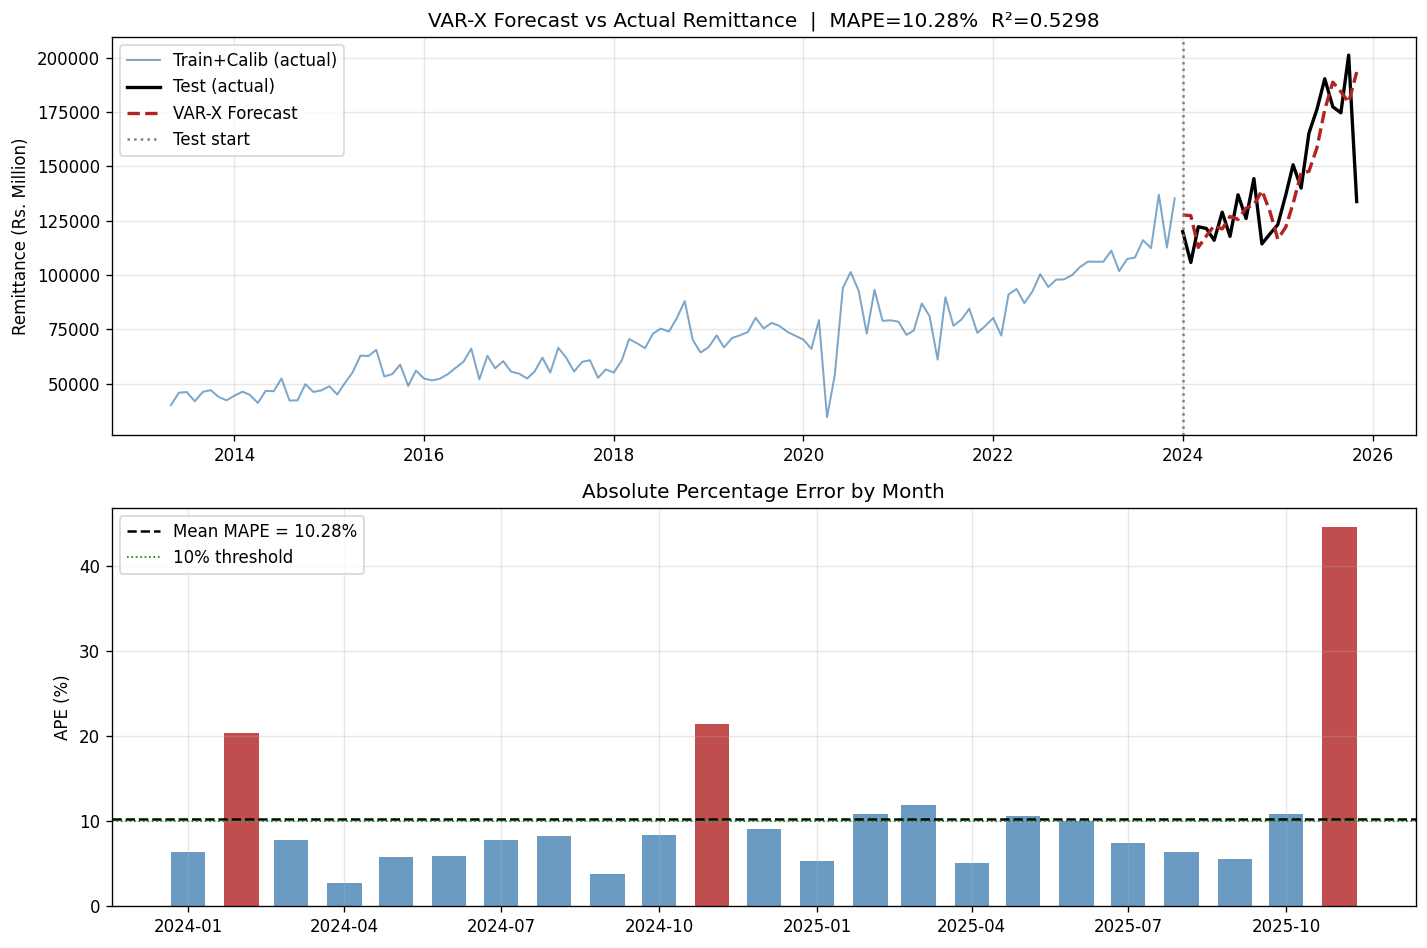

In [13]:
endog_train_calib = endog['2013-05-01':'2023-12-01']

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

axes[0].plot(endog_train_calib.index, endog_train_calib['remittance'],
             color='steelblue', linewidth=1.2, label='Train+Calib (actual)', alpha=0.7)
axes[0].plot(actual_series.index, actual_series,
             color='black', linewidth=2, label='Test (actual)')
axes[0].plot(forecast_series.index, forecast_series,
             color='firebrick', linewidth=2, linestyle='--', label='VAR-X Forecast')
axes[0].axvline(pd.Timestamp('2024-01-01'), color='gray',
                linestyle=':', linewidth=1.5, label='Test start')
axes[0].set_title(f'VAR-X Forecast vs Actual Remittance  |  MAPE={mape:.2f}%  R²={r2:.4f}')
axes[0].set_ylabel('Remittance (Rs. Million)')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].bar(valid.index,
            valid['abs_pct_error'],
            color=['firebrick' if e > 15 else 'steelblue' for e in valid['abs_pct_error']],
            alpha=0.8, width=20)
axes[1].axhline(mape, color='black', linewidth=1.5,
                linestyle='--', label=f'Mean MAPE = {mape:.2f}%')
axes[1].axhline(10, color='green', linewidth=1,
                linestyle=':', label='10% threshold')
axes[1].set_title('Absolute Percentage Error by Month')
axes[1].set_ylabel('APE (%)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('varx_forecast.png', bbox_inches='tight')
plt.show()

## Step 12 — Conformal Prediction Intervals

In [14]:
# Get calibration set forecasts (walk-forward on Jan-Dec 2023)
calib_preds = []
calib_dates = []

for calib_date in endog_calib.index:
    history_endog = endog[endog.index < calib_date]
    history_exog  = exog[exog.index < calib_date]
    history_diff  = history_endog.diff().dropna()
    exog_hist     = history_exog.iloc[1:]

    if len(history_diff) < p_chosen:
        calib_preds.append(np.nan)
        calib_dates.append(calib_date)
        continue

    m      = VAR(history_diff, exog=exog_hist)
    fitted = m.fit(p_chosen)

    last_obs    = history_diff.values[-p_chosen:]
    exog_future = exog.loc[[calib_date]].values
    fc          = fitted.forecast(last_obs, steps=1, exog_future=exog_future)
    delta_rem   = fc[0][0]

    last_level = history_endog['remittance'].iloc[-1]
    calib_preds.append(last_level + delta_rem)
    calib_dates.append(calib_date)

calib_forecast  = pd.Series(calib_preds, index=calib_dates)
calib_actual    = endog_calib['remittance']
calib_residuals = np.abs(calib_actual.values - calib_forecast.values)
calib_residuals = calib_residuals[~np.isnan(calib_residuals)]

# Conformal quantiles
n_calib = len(calib_residuals)
q_90 = np.quantile(calib_residuals, np.ceil((n_calib+1)*0.90)/n_calib, method='higher')
q_80 = np.quantile(calib_residuals, np.ceil((n_calib+1)*0.80)/n_calib, method='higher')

print(f'Calibration residuals (n={n_calib}):')
print(f'  Mean  = {calib_residuals.mean():,.1f} Rs. Million')
print(f'  Std   = {calib_residuals.std():,.1f} Rs. Million')
print(f'  90th percentile half-width = ± {q_90:,.1f} Rs. Million')
print(f'  80th percentile half-width = ± {q_80:,.1f} Rs. Million')

Calibration residuals (n=12):
  Mean  = 7,318.9 Rs. Million
  Std   = 6,742.4 Rs. Million
  90th percentile half-width = ± 22,477.6 Rs. Million
  80th percentile half-width = ± 22,477.6 Rs. Million


## Step 13 — Empirical Coverage and Winkler Score

In [15]:
# Build prediction interval dataframe
pi_df = pd.DataFrame({
    'actual':   actual_series,
    'forecast': forecast_series,
    'lower_90': forecast_series - q_90,
    'upper_90': forecast_series + q_90,
    'lower_80': forecast_series - q_80,
    'upper_80': forecast_series + q_80,
}).dropna()

# Empirical coverage
covered_90  = (pi_df['actual'] >= pi_df['lower_90']) & (pi_df['actual'] <= pi_df['upper_90'])
covered_80  = (pi_df['actual'] >= pi_df['lower_80']) & (pi_df['actual'] <= pi_df['upper_80'])
coverage_90 = covered_90.mean() * 100
coverage_80 = covered_80.mean() * 100

# Winkler score
def winkler_score(actual, lower, upper, alpha):
    width   = upper - lower
    penalty = (2/alpha) * (np.maximum(0, lower-actual) + np.maximum(0, actual-upper))
    return width + penalty

ws_90 = winkler_score(pi_df['actual'].values, pi_df['lower_90'].values, pi_df['upper_90'].values, 0.10).mean()
ws_80 = winkler_score(pi_df['actual'].values, pi_df['lower_80'].values, pi_df['upper_80'].values, 0.20).mean()

print('CONFORMAL PREDICTION — RESULTS')
print(f'  90% interval:  coverage = {coverage_90:.1f}%  |  Winkler = {ws_90:,.1f}')
print(f'  80% interval:  coverage = {coverage_80:.1f}%  |  Winkler = {ws_80:,.1f}')
print()
print('Coverage by month (90% interval):')
print(f'  {"Month":10s}  {"Actual":>10s}  {"Lower":>10s}  {"Upper":>10s}  {"Inside?":>7s}')
print(f'  {"-"*10}  {"-"*10}  {"-"*10}  {"-"*10}  {"-"*7}')
for idx, row in pi_df.iterrows():
    flag = "YES" if covered_90[idx] else "NO"
    print(f'  {idx.strftime("%b %Y"):10s}  {row["actual"]:>10,.0f}  {row["lower_90"]:>10,.0f}  {row["upper_90"]:>10,.0f}  {flag:>7s}')

CONFORMAL PREDICTION — RESULTS
  90% interval:  coverage = 91.3%  |  Winkler = 79,000.1
  80% interval:  coverage = 91.3%  |  Winkler = 61,977.6

Coverage by month (90% interval):
  Month           Actual       Lower       Upper  Inside?
  ----------  ----------  ----------  ----------  -------
  Jan 2024       119,971     105,168     150,123      YES
  Feb 2024       105,775     104,862     149,817      YES
  Mar 2024       122,222      90,231     135,186      YES
  Apr 2024       121,393      95,528     140,483      YES
  May 2024       115,988     100,206     145,162      YES
  Jun 2024       128,905      98,738     143,694      YES
  Jul 2024       117,776     104,473     149,428      YES
  Aug 2024       136,930     103,116     148,071      YES
  Sep 2024       126,000     108,325     153,280      YES
  Oct 2024       144,380     109,722     154,677      YES
  Nov 2024       114,320     116,330     161,286       NO
  Dec 2024       118,800     107,068     152,023      YES
  Jan 20

## Step 14 — Forecast Plot with Prediction Intervals

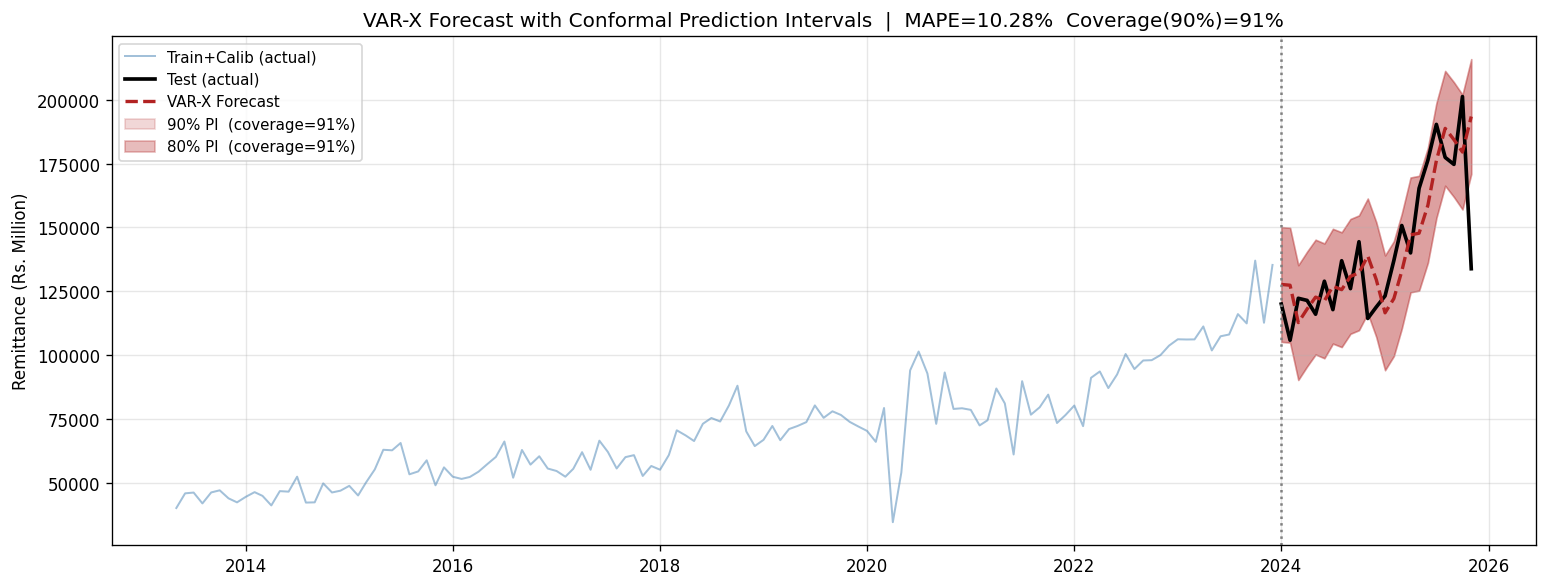

In [16]:
fig, ax = plt.subplots(figsize=(13, 5))

endog_train_calib = endog['2013-05-01':'2023-12-01']
ax.plot(endog_train_calib.index, endog_train_calib['remittance'],
        color='steelblue', linewidth=1.2, alpha=0.5, label='Train+Calib (actual)')
ax.plot(pi_df.index, pi_df['actual'],
        color='black', linewidth=2.2, label='Test (actual)')
ax.plot(pi_df.index, pi_df['forecast'],
        color='firebrick', linewidth=2, linestyle='--', label='VAR-X Forecast')
ax.fill_between(pi_df.index, pi_df['lower_90'], pi_df['upper_90'],
                alpha=0.18, color='firebrick', label=f'90% PI  (coverage={coverage_90:.0f}%)')
ax.fill_between(pi_df.index, pi_df['lower_80'], pi_df['upper_80'],
                alpha=0.30, color='firebrick', label=f'80% PI  (coverage={coverage_80:.0f}%)')
ax.axvline(pd.Timestamp('2024-01-01'), color='gray', linestyle=':', linewidth=1.5)
ax.set_title(f'VAR-X Forecast with Conformal Prediction Intervals  |  MAPE={mape:.2f}%  Coverage(90%)={coverage_90:.0f}%')
ax.set_ylabel('Remittance (Rs. Million)')
ax.legend(loc='upper left', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('varx_conformal.png', bbox_inches='tight')
plt.show()

## Step 15 — Final Results Summary

In [17]:
min_p_exr = min(gc_exr_to_rem[l][0]['ssr_ftest'][1] for l in range(1, max_lags+1))
min_p_rem = min(gc_rem_to_exr[l][0]['ssr_ftest'][1] for l in range(1, max_lags+1))

if   min_p_exr < 0.05 and min_p_rem < 0.05: direction = 'BIDIRECTIONAL'
elif min_p_exr < 0.05:                       direction = 'UNIDIRECTIONAL (exchange_rate -> remittance)'
elif min_p_rem < 0.05:                       direction = 'UNIDIRECTIONAL (remittance -> exchange_rate)'
else:                                         direction = 'NO significant Granger causality'

mape_2024 = valid.loc[valid.index.year==2024, 'abs_pct_error'].mean()
mape_2025 = valid.loc[valid.index.year==2025, 'abs_pct_error'].mean()
mape_no_nov = valid[valid.index != '2025-11-01']['abs_pct_error'].mean()

print('=' * 60)
print('  VAR-X — FINAL RESULTS SUMMARY')
print('=' * 60)
print(f'  Endogenous  : remittance, exchange_rate')
print(f'  Exogenous   : oil_price, dofe_lag3, dofe_lag6, dofe_lag9, covid_shock')
print(f'  Lag order   : p={p_chosen} (BIC selected p={p_bic}, minimum 1 enforced)')
print(f'  Pearson  r  : {pearson_r:.4f}  (p={pearson_p:.2e})')
print(f'  Spearman r  : {spearman_r:.4f}  (p={spearman_p:.2e})')
print(f'  Granger     : {direction}')
print(f'  DW          : {dw[0]:.4f} (remittance)  {dw[1]:.4f} (exchange_rate)')
print()
print(f'  FORECAST ACCURACY (Jan 2024 – Nov 2025, n=23):')
print(f'    MAPE        = {mape:.2f}%')
print(f'    MAPE 2024   = {mape_2024:.2f}%  (n=12)')
print(f'    MAPE 2025   = {mape_2025:.2f}%  (n=11)')
print(f'    MAPE w/o Nov 2025 = {mape_no_nov:.2f}%')
print(f'    RMSE        = {rmse:,.1f} Rs. Million')
print(f'    MAE         = {mae:,.1f} Rs. Million')
print(f'    R2          = {r2:.4f}')
print()
print(f'  CONFORMAL PREDICTION (calibration n={n_calib}):')
print(f'    90% half-width  = ± {q_90:,.1f} Rs. Million')
print(f'    80% half-width  = ± {q_80:,.1f} Rs. Million')
print(f'    Coverage (90%)  = {coverage_90:.1f}%')
print(f'    Coverage (80%)  = {coverage_80:.1f}%')
print(f'    Winkler (90%)   = {ws_90:,.1f}')
print(f'    Winkler (80%)   = {ws_80:,.1f}')
print(f'  Ghimire (2026) VAR-X MAPE : 8.10%  (test period 2018-2023)')
print('=' * 60)

  VAR-X — FINAL RESULTS SUMMARY
  Endogenous  : remittance, exchange_rate
  Exogenous   : oil_price, dofe_lag3, dofe_lag6, dofe_lag9, covid_shock
  Lag order   : p=1 (BIC selected p=0, minimum 1 enforced)
  Pearson  r  : 0.8580  (p=9.00e-35)
  Spearman r  : 0.8477  (p=3.59e-33)
  Granger     : NO significant Granger causality
  DW          : 2.2545 (remittance)  2.0315 (exchange_rate)

  FORECAST ACCURACY (Jan 2024 – Nov 2025, n=23):
    MAPE        = 10.28%
    MAPE 2024   = 8.99%  (n=12)
    MAPE 2025   = 11.69%  (n=11)
    MAPE w/o Nov 2025 = 8.72%
    RMSE        = 18,102.7 Rs. Million
    MAE         = 14,242.1 Rs. Million
    R2          = 0.5298

  CONFORMAL PREDICTION (calibration n=12):
    90% half-width  = ± 22,477.6 Rs. Million
    80% half-width  = ± 22,477.6 Rs. Million
    Coverage (90%)  = 91.3%
    Coverage (80%)  = 91.3%
    Winkler (90%)   = 79,000.1
    Winkler (80%)   = 61,977.6
  Ghimire (2026) VAR-X MAPE : 8.10%  (test period 2018-2023)
